# 1D-CNN on Raw EEG + Power

This notebook trains a leakage-safe 1D-CNN using:

- `raw_values` (512-point EEG waveform)
- `eeg_power` (8-band power vector, upsampled to match sequence length)

Splits are inherited from `outputs/processed/features_with_split.csv` (subject-wise).

Pipeline:

1. Load raw EEG + split assignments.
2. Optionally aggregate labels to major classes (recommended).
3. Build 2-channel sequence tensors `[raw, power_interp]`.
4. Train 1D-CNN with class-weighted loss.
5. Evaluate on test with Accuracy, Macro-F1, and AUC (OvR).


In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
RAW_PATH = Path('EEG/eeg-data.csv')
SPLIT_PATH = Path('outputs/processed/features_with_split.csv')
REPORT_DIR = Path('outputs/reports')
REPORT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Keep this True unless you explicitly want all fine-grained labels.
USE_MAJOR_CLASSES = True

BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 35
EARLY_STOP_PATIENCE = 7

torch.manual_seed(SEED)
np.random.seed(SEED)

print('Device:', DEVICE)
print('Raw file exists:', RAW_PATH.exists())
print('Split file exists:', SPLIT_PATH.exists())

Device: cpu
Raw file exists: True
Split file exists: True


In [3]:
def parse_num_list(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    if text[0] == '[' and text[-1] == ']':
        text = text[1:-1]
    arr = np.fromstring(text, sep=',', dtype=np.float32)
    if arr.size == 0:
        return None
    return arr

def fix_len(arr, n):
    if arr is None:
        return None
    if arr.size == n:
        return arr.astype(np.float32)
    if arr.size > n:
        return arr[:n].astype(np.float32)
    out = np.zeros(n, dtype=np.float32)
    out[:arr.size] = arr
    return out

def power_to_seq(power, n=512):
    power = fix_len(power, 8)
    if power is None:
        return None
    x_old = np.arange(8, dtype=np.float32)
    x_new = np.linspace(0, 7, n, dtype=np.float32)
    return np.interp(x_new, x_old, power).astype(np.float32)

def to_major_class(label: str) -> str:
    s = str(label).strip()
    low = s.lower()
    if low.startswith('math'):
        return 'math'
    if low.startswith('video'):
        return 'video'
    if low.startswith('thinkofitems'):
        return 'thinkOfItems'
    if low.startswith('music'):
        return 'music'
    if low.startswith('relax'):
        return 'relax'
    if low.startswith('blink'):
        return 'blink'
    if low.startswith('color'):
        return 'color'
    if low.startswith('ready'):
        return 'ready'
    base = re.split(r'[-_]', s)[0]
    base = re.sub(r'\d+$', '', base)
    return base or s

In [4]:
raw_df = pd.read_csv(RAW_PATH)
split_df = pd.read_csv(SPLIT_PATH)

# Reuse existing leakage-safe split assignment by merging on stable keys.
join_keys = ['id', 'indra_time', 'createdAt', 'label']
split_key = split_df[join_keys + ['split']].drop_duplicates(join_keys)

df = raw_df.merge(split_key, on=join_keys, how='left')
df = df[df['split'].isin(['train', 'val', 'test'])].copy()

if USE_MAJOR_CLASSES:
    df['target'] = df['label'].map(to_major_class)
else:
    df['target'] = df['label'].astype(str)

print('Rows with split:', len(df))
print('Subjects:', df['id'].nunique())
print('Target classes:', df['target'].nunique())
print()
print(pd.crosstab(df['split'], df['target']))

Rows with split: 9959
Subjects: 30
Target classes: 8

target  blink  color  math  music  ready  relax  thinkOfItems  video
split                                                               
test       61    521   181    174     79    176           251    185
train     264   2255   775    771    336    776          1106    775
val        46    414   141    139     57    140           197    139


In [5]:
def build_arrays(frame):
    xs = []
    ys = []

    for _, r in frame.iterrows():
        raw = fix_len(parse_num_list(r.get('raw_values')), 512)
        power = power_to_seq(parse_num_list(r.get('eeg_power')), 512)

        if raw is None or power is None:
            continue

        x = np.stack([raw, power], axis=0)  # [2, 512]
        xs.append(x)
        ys.append(r['target'])

    x = np.asarray(xs, dtype=np.float32)
    y = np.asarray(ys)
    return x, y

train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'val'].copy()
test_df = df[df['split'] == 'test'].copy()

x_train, y_train_text = build_arrays(train_df)
x_val, y_val_text = build_arrays(val_df)
x_test, y_test_text = build_arrays(test_df)

classes = sorted(np.unique(y_train_text).tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}

y_train = np.array([class_to_idx[c] for c in y_train_text], dtype=np.int64)
y_val = np.array([class_to_idx[c] for c in y_val_text], dtype=np.int64)
y_test = np.array([class_to_idx[c] for c in y_test_text], dtype=np.int64)

print('Tensor-ready shapes:')
print('  train:', x_train.shape, y_train.shape)
print('  val  :', x_val.shape, y_val.shape)
print('  test :', x_test.shape, y_test.shape)
print('Classes:', classes)

Tensor-ready shapes:
  train: (7058, 2, 512) (7058,)
  val  : (1273, 2, 512) (1273,)
  test : (1628, 2, 512) (1628,)
Classes: ['blink', 'color', 'math', 'music', 'ready', 'relax', 'thinkOfItems', 'video']


In [6]:
# Train-set normalization only (avoid leakage).
ch_mean = x_train.mean(axis=(0, 2), keepdims=True)
ch_std = x_train.std(axis=(0, 2), keepdims=True) + 1e-6

x_train_n = (x_train - ch_mean) / ch_std
x_val_n = (x_val - ch_mean) / ch_std
x_test_n = (x_test - ch_mean) / ch_std

train_ds = TensorDataset(torch.tensor(x_train_n), torch.tensor(y_train))
val_ds = TensorDataset(torch.tensor(x_val_n), torch.tensor(y_val))
test_ds = TensorDataset(torch.tensor(x_test_n), torch.tensor(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print('Batches | train:', len(train_loader), 'val:', len(val_loader), 'test:', len(test_loader))

Batches | train: 111 val: 20 test: 26


In [13]:
class EEG1DCNN(nn.Module):
    def __init__(self, n_classes, in_channels=2, seq_len=512, dropout=0.2):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Conv1d(256, 512, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(512),

            nn.Conv1d(512, 1024, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(1024),

            nn.Dropout(dropout),
        )

        # Infer flattened size once from a dummy input so the architecture stays flexible.
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, seq_len)
            conv_out = self.conv(dummy)
            flat_dim = conv_out.numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 4096),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(4096, 2048),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(1024, 128),
            nn.ReLU(),

            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.conv(x)
        return self.classifier(x)


def run_eval(model, loader):
    model.eval()
    all_logits = []
    all_y = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            all_logits.append(logits.cpu())
            all_y.append(yb)
    logits = torch.cat(all_logits, dim=0).numpy()
    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    y_pred = probs.argmax(axis=1)

    out = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'y_true': y_true,
        'y_pred': y_pred,
        'probs': probs,
    }
    try:
        out['auc_macro_ovr'] = float(roc_auc_score(y_true, probs, multi_class='ovr', average='macro'))
    except Exception:
        out['auc_macro_ovr'] = float('nan')
    return out

In [14]:
weights = compute_class_weight(class_weight='balanced', classes=np.arange(len(classes)), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

model = EEG1DCNN(n_classes=len(classes), in_channels=2, seq_len=512).to(DEVICE)
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model.Summary(input_size=(2, 512)))
print(f"Trainable params: {param_count:,}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = {'train_loss': [], 'val_f1': [], 'val_acc': [], 'val_auc': []}
best_state = None
best_val_f1 = -1.0
epochs_no_improve = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_ds)
    val_metrics = run_eval(model, val_loader)

    history['train_loss'].append(train_loss)
    history['val_f1'].append(val_metrics['f1_macro'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_auc'].append(val_metrics['auc_macro_ovr'])

    print(f"Epoch {epoch:02d} | loss={train_loss:.4f} | val_f1={val_metrics['f1_macro']:.4f} | val_acc={val_metrics['accuracy']:.4f} | val_auc={val_metrics['auc_macro_ovr']:.4f}")

    if val_metrics['f1_macro'] > best_val_f1:
        best_val_f1 = val_metrics['f1_macro']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print('Best val macro-F1:', round(best_val_f1, 4))

EEG1DCNN(
  (conv): Sequential(
    (0): Conv1d(2, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): ReLU()
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv1d(64, 128, kernel_size=(5,), stride=(2,), padding=(2,))
    (7): ReLU()
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv1d(128, 256, kernel_size=(5,), stride=(2,), padding=(2,))
    (10): ReLU()
    (11): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Conv1d(256, 512, kernel_size=(7,), stride=(2,), padding=(3,))
    (13): ReLU()
    (14): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): Conv1d(512, 1024, kernel_size=(7,), stride=(2,), padding=(3,))
    (16): ReL

KeyboardInterrupt: 

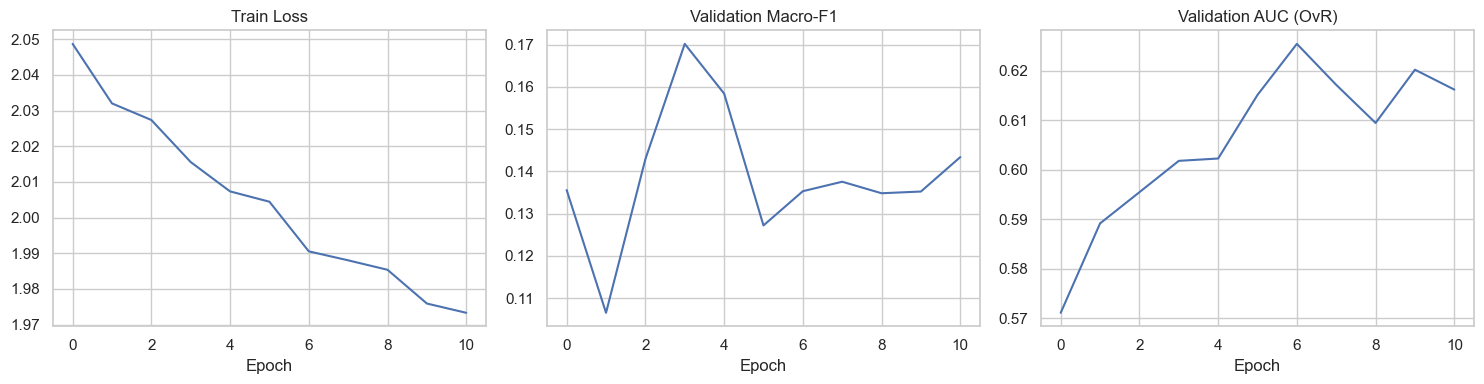

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'])
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_f1'])
axes[1].set_title('Validation Macro-F1')
axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_auc'])
axes[2].set_title('Validation AUC (OvR)')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

In [10]:
test_metrics = run_eval(model, test_loader)

print('Test metrics:')
print('  Accuracy      :', round(test_metrics['accuracy'], 4))
print('  Macro-F1      :', round(test_metrics['f1_macro'], 4))
print('  AUC Macro OvR :', round(test_metrics['auc_macro_ovr'], 4))

target_names = classes
report = classification_report(
    test_metrics['y_true'],
    test_metrics['y_pred'],
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T
display(report_df)

Test metrics:
  Accuracy      : 0.1407
  Macro-F1      : 0.1145
  AUC Macro OvR : 0.5647


,precision,recall,f1-score,support
blink,0.079618,0.409836,0.133333,61.000000
color,0.379032,0.090211,0.145736,521.000000
math,0.100000,0.005525,0.010471,181.000000
music,0.138132,0.408046,0.206395,174.000000
ready,0.034483,0.088608,0.049645,79.000000
relax,0.111111,0.062500,0.080000,176.000000
thinkOfItems,0.209559,0.227092,0.217973,251.000000
video,0.108696,0.054054,0.072202,185.000000
accuracy,0.140663,0.140663,0.140663,0.140663
macro avg,0.145079,0.168234,0.114470,1628.000000


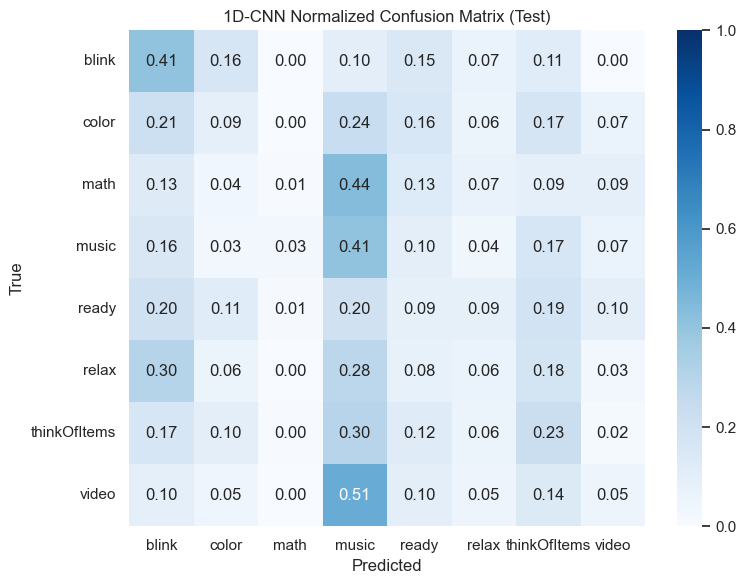

In [11]:
cm = confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], normalize='true')
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, cmap='Blues', vmin=0, vmax=1, annot=True, fmt='.2f')
plt.title('1D-CNN Normalized Confusion Matrix (Test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [ ]:
artifact = {
    'model': '1d_cnn_raw_plus_power',
    'use_major_classes': bool(USE_MAJOR_CLASSES),
    'classes': classes,
    'config': {
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'weight_decay': WEIGHT_DECAY,
        'max_epochs': MAX_EPOCHS,
        'early_stop_patience': EARLY_STOP_PATIENCE,
        'seed': SEED,
    },
    'data': {
        'train_rows': int(len(train_ds)),
        'val_rows': int(len(val_ds)),
        'test_rows': int(len(test_ds)),
    },
    'best_val_f1': float(best_val_f1),
    'history': history,
    'test_metrics': {
        'accuracy': float(test_metrics['accuracy']),
        'f1_macro': float(test_metrics['f1_macro']),
        'auc_macro_ovr': float(test_metrics['auc_macro_ovr']),
    },
}

out_path = REPORT_DIR / 'cnn_1d_raw_power_results.json'
out_path.write_text(json.dumps(artifact, indent=2), encoding='utf-8')
print('Saved:', out_path)